--- Resumen del Modelo de Regresión Polinómica (Cuadrático) ---
                            OLS Regression Results                            
Dep. Variable:          Trigliceridos   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     24.93
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.84e-09
Time:                        21:44:03   Log-Likelihood:                -411.11
No. Observations:                 100   AIC:                             828.2
Df Residuals:                      97   BIC:                             836.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

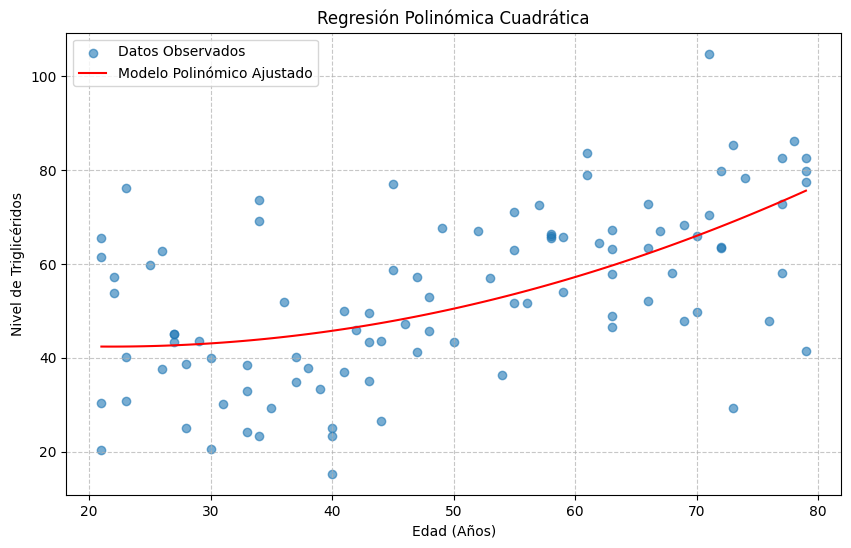

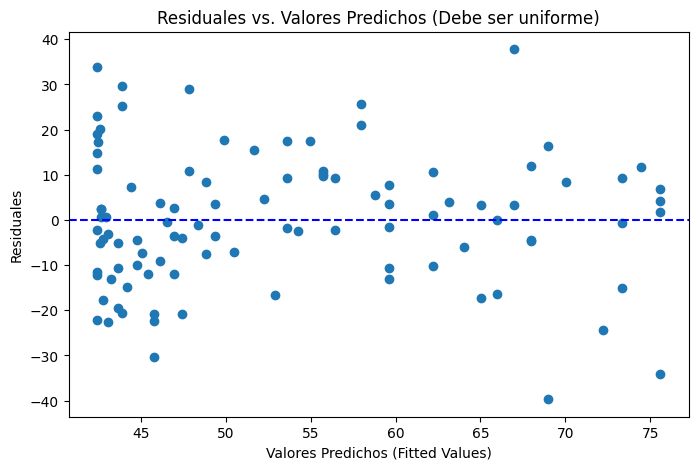

In [ ]:
# Implementación en Python
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Datos de ejemplo 
# Usaremos datos ficticios que muestran una relación curva con la edad.
np.random.seed(42)
edad = np.random.randint(20, 80, 100)
# Creamos la edad al cuadrado (la variable polinómica)
edad_cuadrado = edad**2 

# Relación: Triglicéridos = a + b1*edad + b2*edad^2 + error
# Donde la relación con edad^2 es positiva para simular una curva.
trigliceridos = 50 - 0.5 * edad + 0.01 * edad_cuadrado + np.random.normal(0, 15, 100)

# Crear DataFrame y definir variables
data = pd.DataFrame({'Edad': edad, 'Edad_Cuadrado': edad_cuadrado, 'Trigliceridos': trigliceridos})

# Definir predictores (X) y respuesta (Y)
# Note que incluimos tanto Edad como Edad_Cuadrado
X = data[['Edad', 'Edad_Cuadrado']]
Y = data['Trigliceridos']

# Añadir la constante (Intercepto, β0)
X = sm.add_constant(X) 

# Ajuste del modelo de Regresión Polinómica (MLRM)
modelo_polinomico = sm.OLS(Y, X).fit()

print("--- Resumen del Modelo de Regresión Polinómica (Cuadrático) ---")
print(modelo_polinomico.summary())

# --- Visualización de la Curva Ajustada ---
# Generar puntos para dibujar la curva
x_fit = np.linspace(edad.min(), edad.max(), 100)
X_fit = pd.DataFrame({'Edad': x_fit, 'Edad_Cuadrado': x_fit**2})
X_fit = sm.add_constant(X_fit, has_constant='add')

y_pred = modelo_polinomico.predict(X_fit)

plt.figure(figsize=(10, 6))
plt.scatter(data['Edad'], data['Trigliceridos'], label='Datos Observados', alpha=0.6)
plt.plot(x_fit, y_pred, color='red', label='Modelo Polinómico Ajustado')
plt.xlabel('Edad (Años)')
plt.ylabel('Nivel de Triglicéridos')
plt.title('Regresión Polinómica Cuadrática')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("rpc.png")
plt.show()

# --- Análisis de Residuales para Linealidad ---
# Un residual plot plano (distribución uniforme alrededor de cero)
# es un buen indicador de que el modelo polinómico capturó la no-linealidad.
residuales = modelo_polinomico.resid
predichos = modelo_polinomico.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(predichos, residuales)
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel('Valores Predichos (Fitted Values)')
plt.ylabel('Residuales')
plt.title('Residuales vs. Valores Predichos (Debe ser uniforme)')
plt.savefig("arl.png")
plt.show()



Call:
lm(formula = trigliceridos ~ edad + I(edad^2), data = datos_clinicos)

Residuals:
    Min      1Q  Median      3Q     Max 
-19.580  -5.662  -1.109   6.655  21.218 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 87.631264   9.878071   8.871 2.16e-12 ***
edad         4.156348   0.426683   9.741 8.13e-14 ***
I(edad^2)   -0.046349   0.004215 -10.996 8.17e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.124 on 58 degrees of freedom
Multiple R-squared:  0.7489,	Adjusted R-squared:  0.7402 
F-statistic: 86.47 on 2 and 58 DF,  p-value: < 2.2e-16


Analysis of Variance Table

Model 1: trigliceridos ~ edad
Model 2: trigliceridos ~ edad + I(edad^2)
  Res.Df     RSS Df Sum of Sq      F    Pr(>F)    
1     59 14894.8                                  
2     58  4828.4  1     10066 120.92 8.171e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


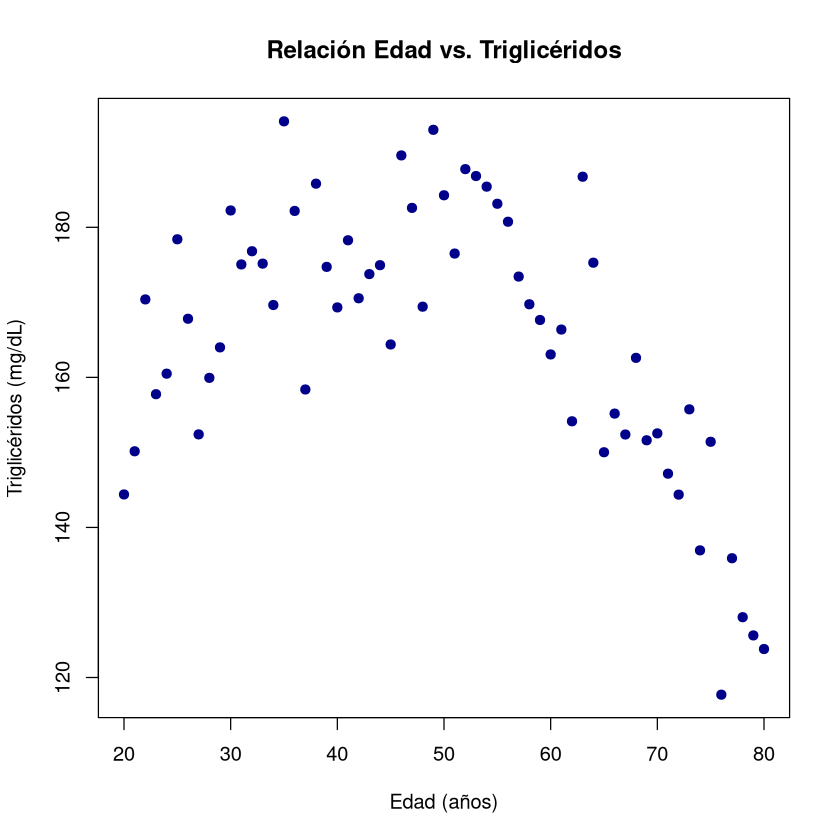

In [1]:
# --- Script de Regresión Polinómica Cuadrática ---

# 1. Generación de datos ficticios basados en lógica clínica
# Se simula una relación donde los triglicéridos suben con la edad 
# pero comienzan a descender o estabilizarse después de los 55 años.
set.seed(123)
edad <- seq(20, 80)
trigliceridos <- 80 + 4.5*edad - 0.05*edad^2 + rnorm(length(edad), 0, 10)

datos_clinicos <- data.frame(edad, trigliceridos)

# 2. Ajuste del modelo cuadrático
# El uso de I(edad^2) permite incluir la potencia sin modificar el dataset [16]
modelo_quad <- lm(trigliceridos ~ edad + I(edad^2), data = datos_clinicos)

# 3. Visualización de los parámetros estimados
summary(modelo_quad)

# 4. Comparación con el modelo lineal simple (Rigurosidad científica)
# La prueba ANOVA permite determinar si la adición del término cuadrático 
# mejora significativamente el ajuste del modelo [17], [18].
modelo_lineal <- lm(trigliceridos ~ edad, data = datos_clinicos)
tabla_comparativa <- anova(modelo_lineal, modelo_quad)
print(tabla_comparativa)

# 5. Representación Gráfica
plot(datos_clinicos$edad, datos_clinicos$trigliceridos, 
     pch = 19, col = "darkblue",
     main = "Relación Edad vs. Triglicéridos",
     xlab = "Edad (años)", ylab = "Triglicéridos (mg/dL)")

# Superposición de la curva ajustada usando la función curve()
# Extraemos los coeficientes beta del modelo [19], [15]
b0 <- coef(modelo_quad)[20]
b1 <- coef(modelo_quad)[21]
b2 <- coef(modelo_quad)[22]

curve(b0 + b1*x + b2*x^2, add = TRUE, col = "red", lwd = 2)